# Combined Chromatin Deconvolution Run
March 7, 2024

Trial combined chromatin deconvolution model run

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import load_yl_rg1_vst_config
from cc_src.combined_chromatin_model import CombinedChromatinModel

config1 = load_yl_rg1_vst_config(1)
config2 = load_yl_rg1_vst_config(2)
combined_model = CombinedChromatinModel(config1, config2)


In [18]:
gene_name = "CLB2"
combined_model.load_combined_mnase_gene(gene_name)

Loading MNase reads for YPR119W/CLB2...Already loaded chromosome reads for 16. Using cache.
Done.
Loading MNase reads for YPR119W/CLB2...Already loaded chromosome reads for 16. Using cache.
Done.


In [19]:
combined_model.setup_deconv_model()

In [20]:
H = np.zeros(combined_model.deconv_model.H.shape)
H.shape

np.sum(H, axis=0).shape

(227,)

In [21]:
# Deconvolve
combined_model.deconvolve(verbose=True)

Deconvolving combined model with gamma=0.006, gamma_prime=0
                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Mar 07 05:12:01 PM: Your problem has 181600 variables, 1 constraints, and 1 parameters.
(CVXPY) Mar 07 05:12:01 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 07 05:12:01 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 07 05:12:01 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Mar 07 05:12:01 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Mar 07 05:12:01 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr

(CVXPY) Mar 07 05:13:18 PM: 25  7.7e-03  7.7e-03  1.1e-01  1.45e-01   2.534379795e+03   2.535006300e+03   7.7e-03  27.16 
(CVXPY) Mar 07 05:13:19 PM: 26  7.2e-03  7.2e-03  1.0e-01  1.42e-01   2.533994554e+03   2.534604503e+03   7.2e-03  27.50 
(CVXPY) Mar 07 05:13:19 PM: 27  6.6e-03  6.6e-03  9.0e-02  1.37e-01   2.533436909e+03   2.534024083e+03   6.6e-03  27.83 
(CVXPY) Mar 07 05:13:19 PM: 28  6.1e-03  6.1e-03  8.2e-02  1.27e-01   2.532903435e+03   2.533470586e+03   6.1e-03  28.17 
(CVXPY) Mar 07 05:13:20 PM: 29  5.8e-03  5.8e-03  7.7e-02  1.14e-01   2.532517243e+03   2.533071119e+03   5.8e-03  28.51 
(CVXPY) Mar 07 05:13:20 PM: 30  5.0e-03  5.0e-03  6.4e-02  1.05e-01   2.531415408e+03   2.531934019e+03   5.0e-03  28.89 
(CVXPY) Mar 07 05:13:20 PM: 31  4.6e-03  4.6e-03  5.8e-02  8.28e-02   2.530784980e+03   2.531286063e+03   4.6e-03  29.24 
(CVXPY) Mar 07 05:13:21 PM: 32  3.7e-03  3.7e-03  4.6e-02  7.31e-02   2.529188134e+03   2.529647154e+03   3.7e-03  29.58 
(CVXPY) Mar 07 05:13:21 

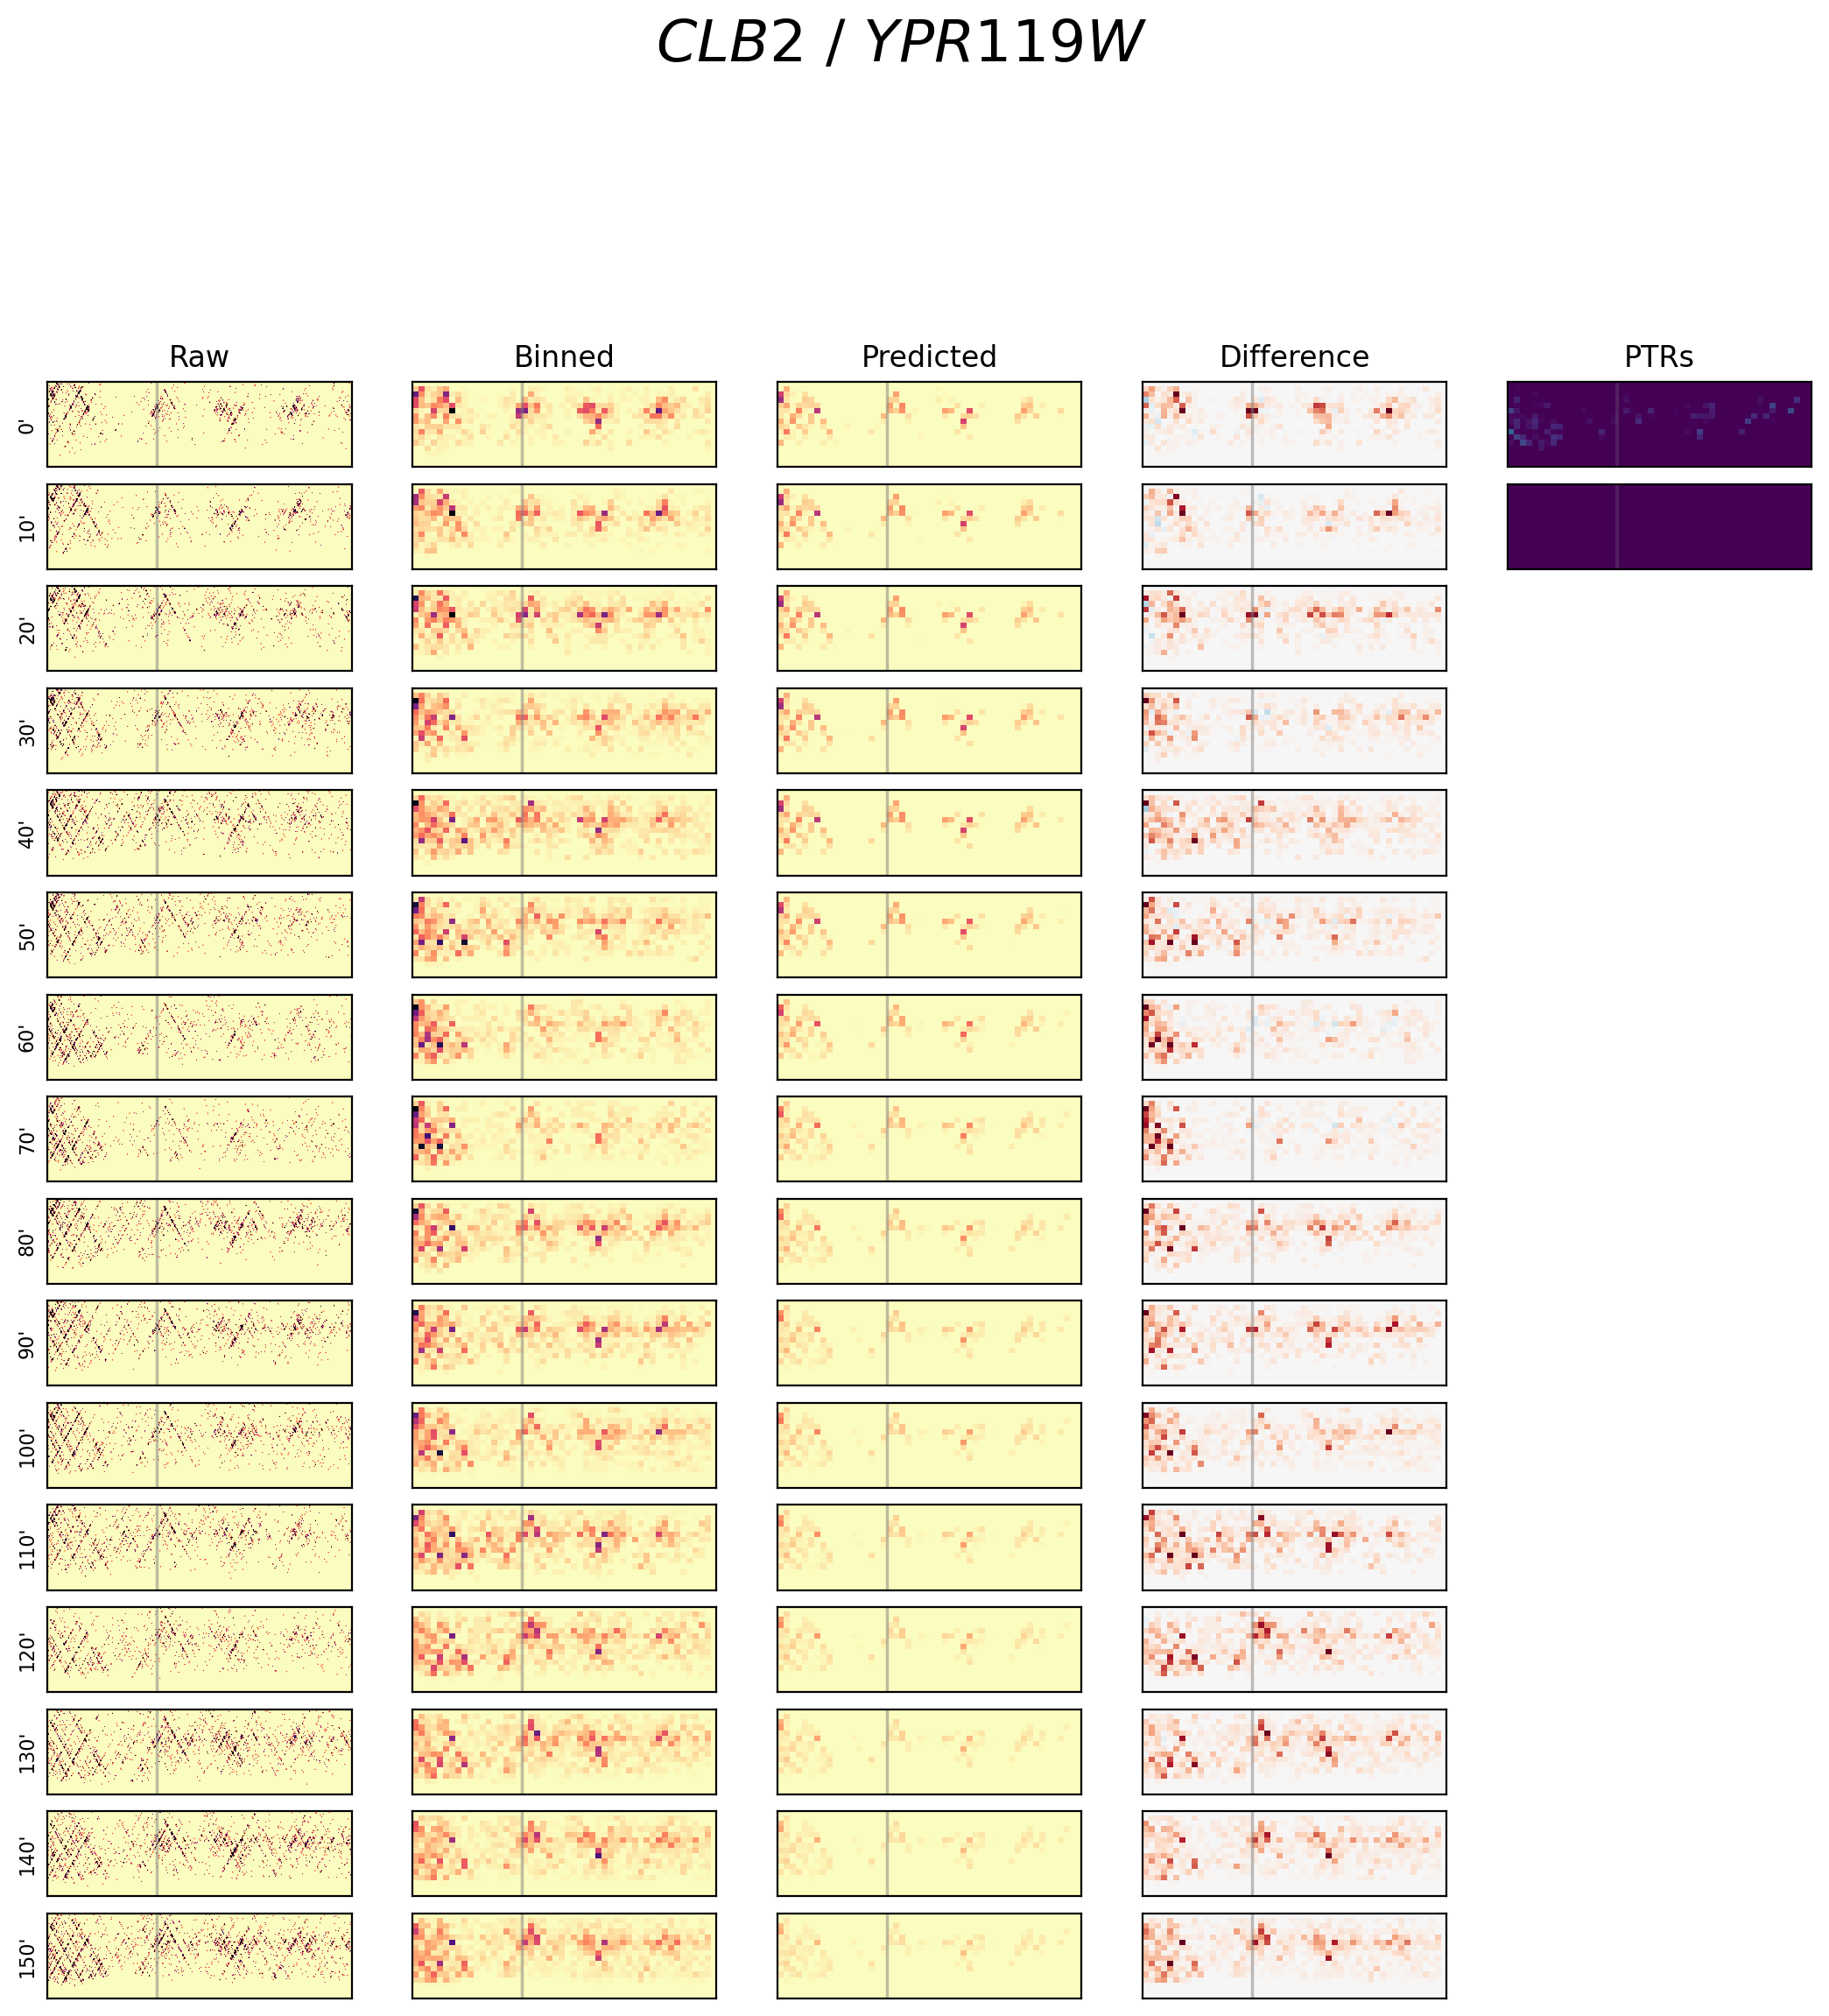

In [22]:
fig = combined_model.plot_raw_prediction(1, vmax=50)

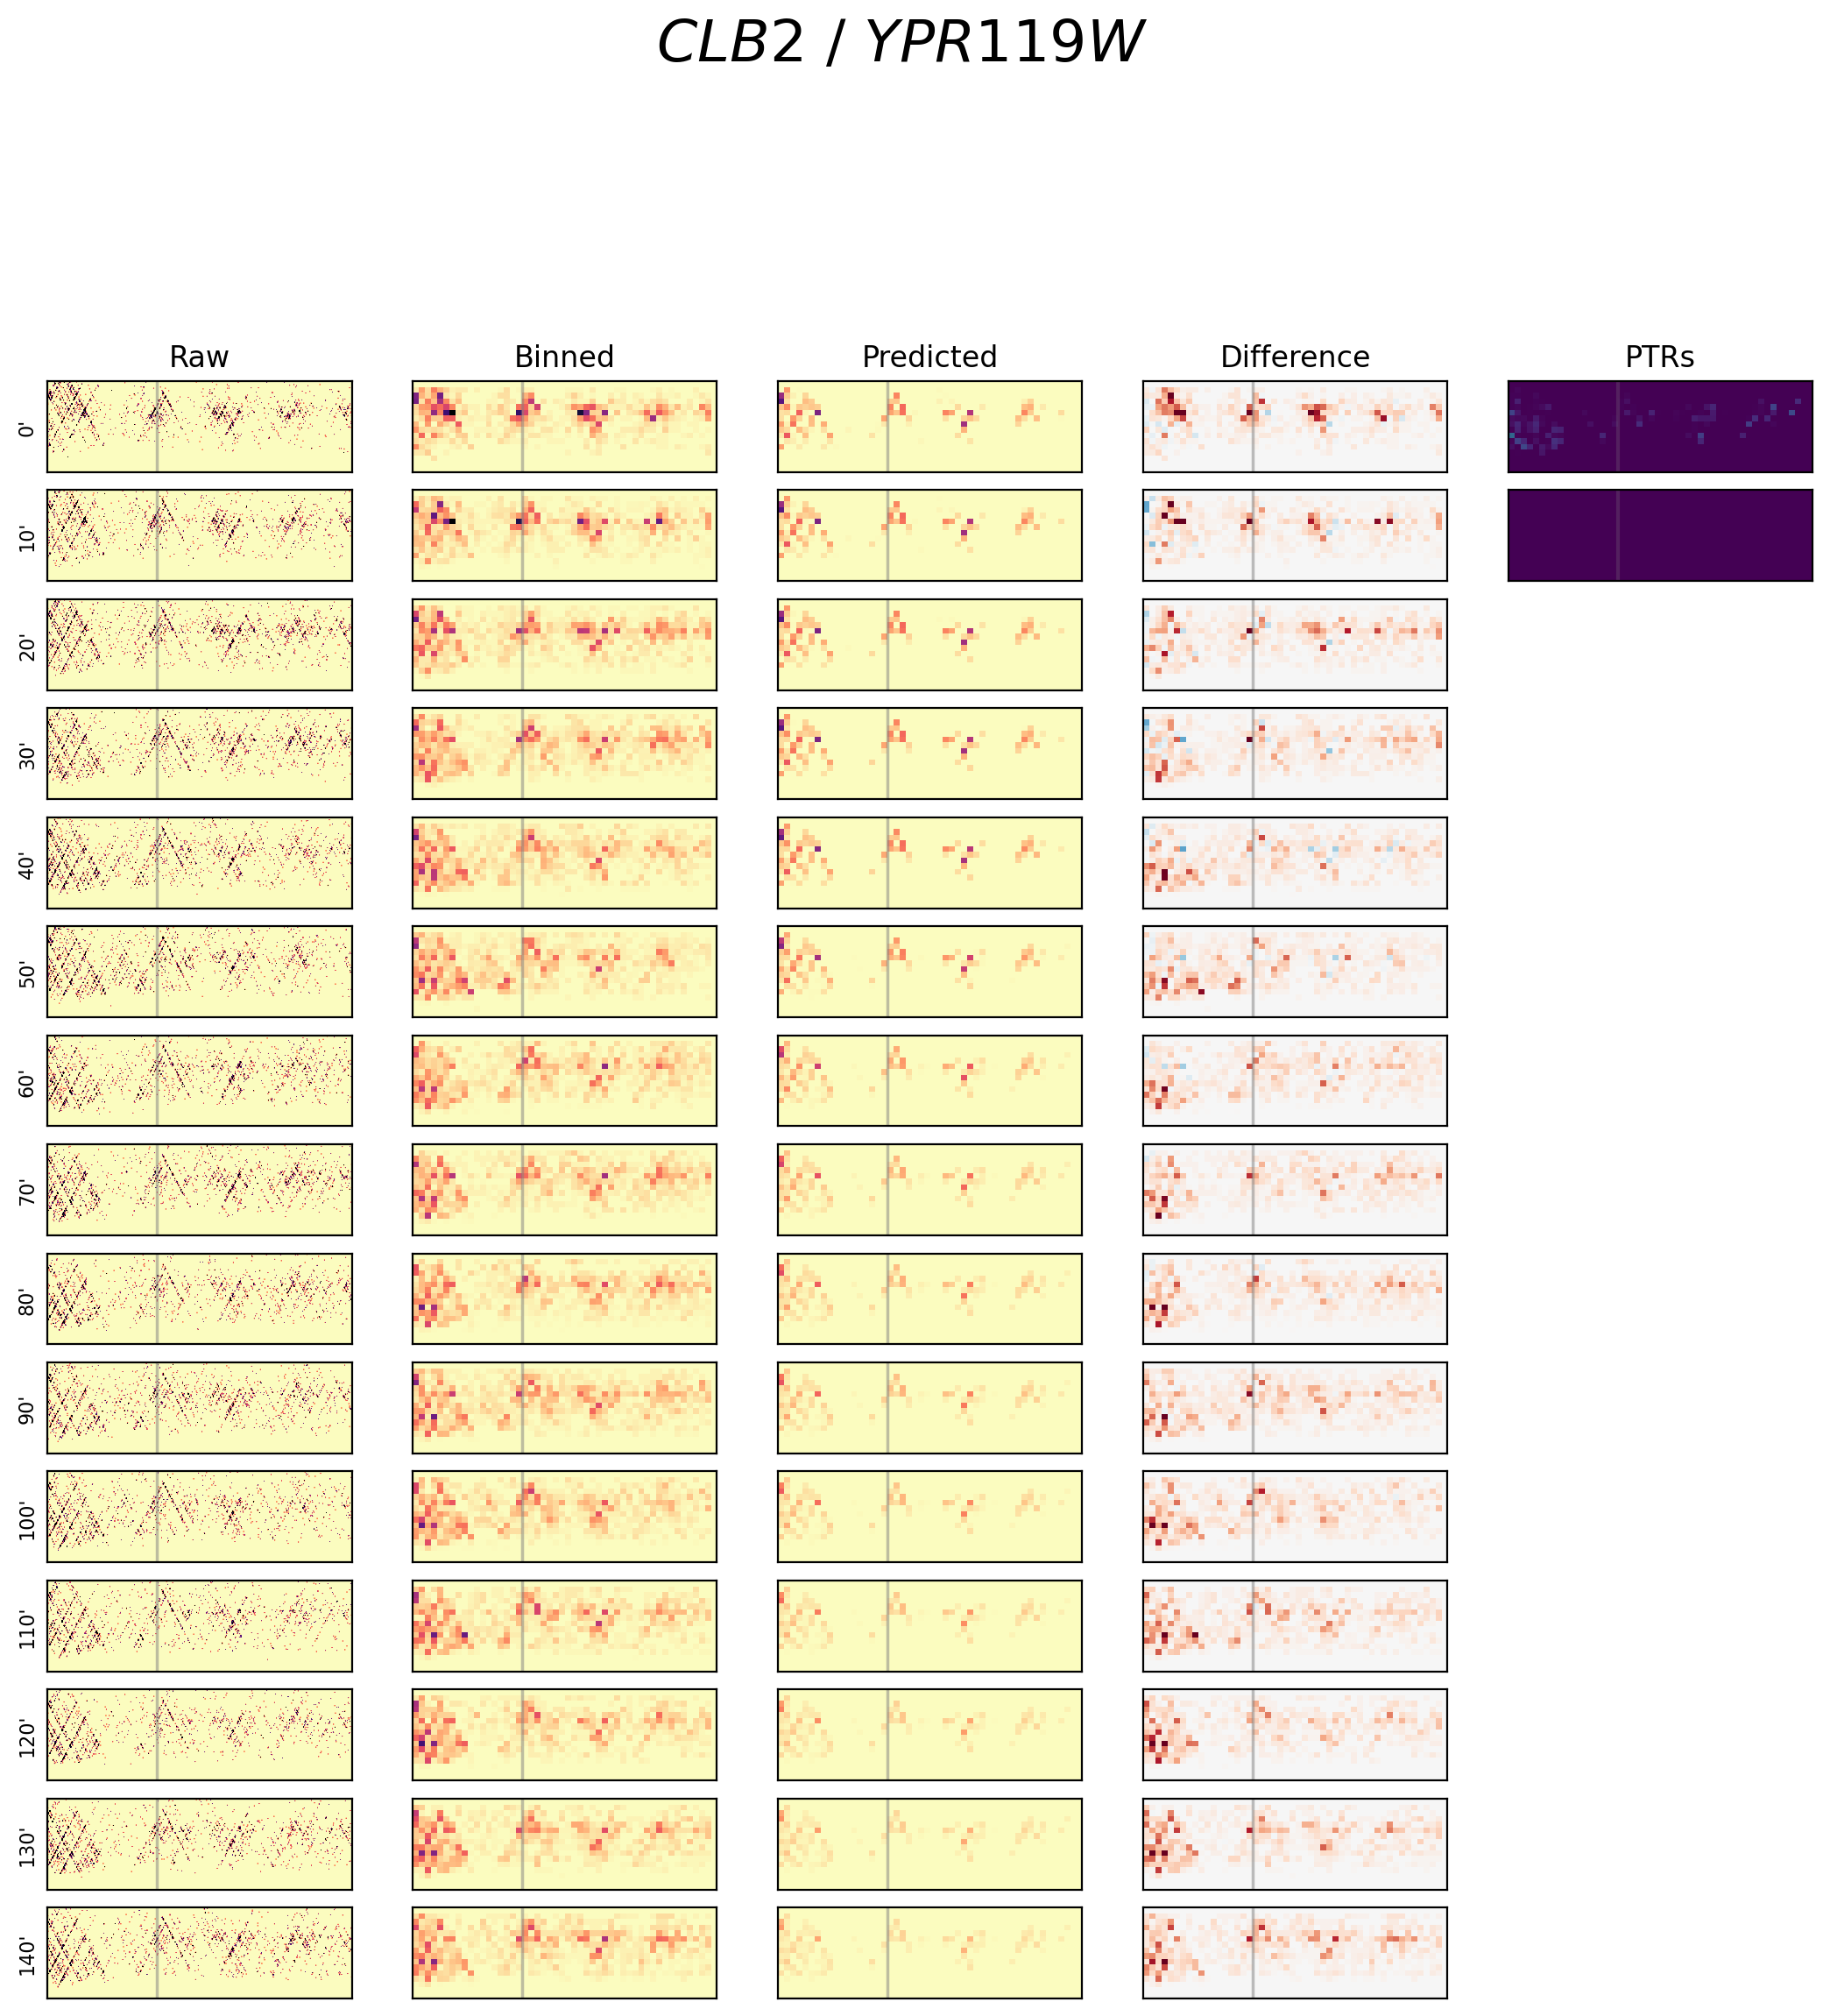

In [23]:
fig = combined_model.plot_raw_prediction(2, vmax=50)

In [24]:
# Deconvolve the combined gene expression model
from src.config import load_combined_yl_alpha_vst_gene_expression_config
from src.model import Model

combined_ge_config = load_combined_yl_alpha_vst_gene_expression_config()
ge_model = Model(combined_ge_config, gene_name)
ge_model.deconvolve_find_optimal_gamma()

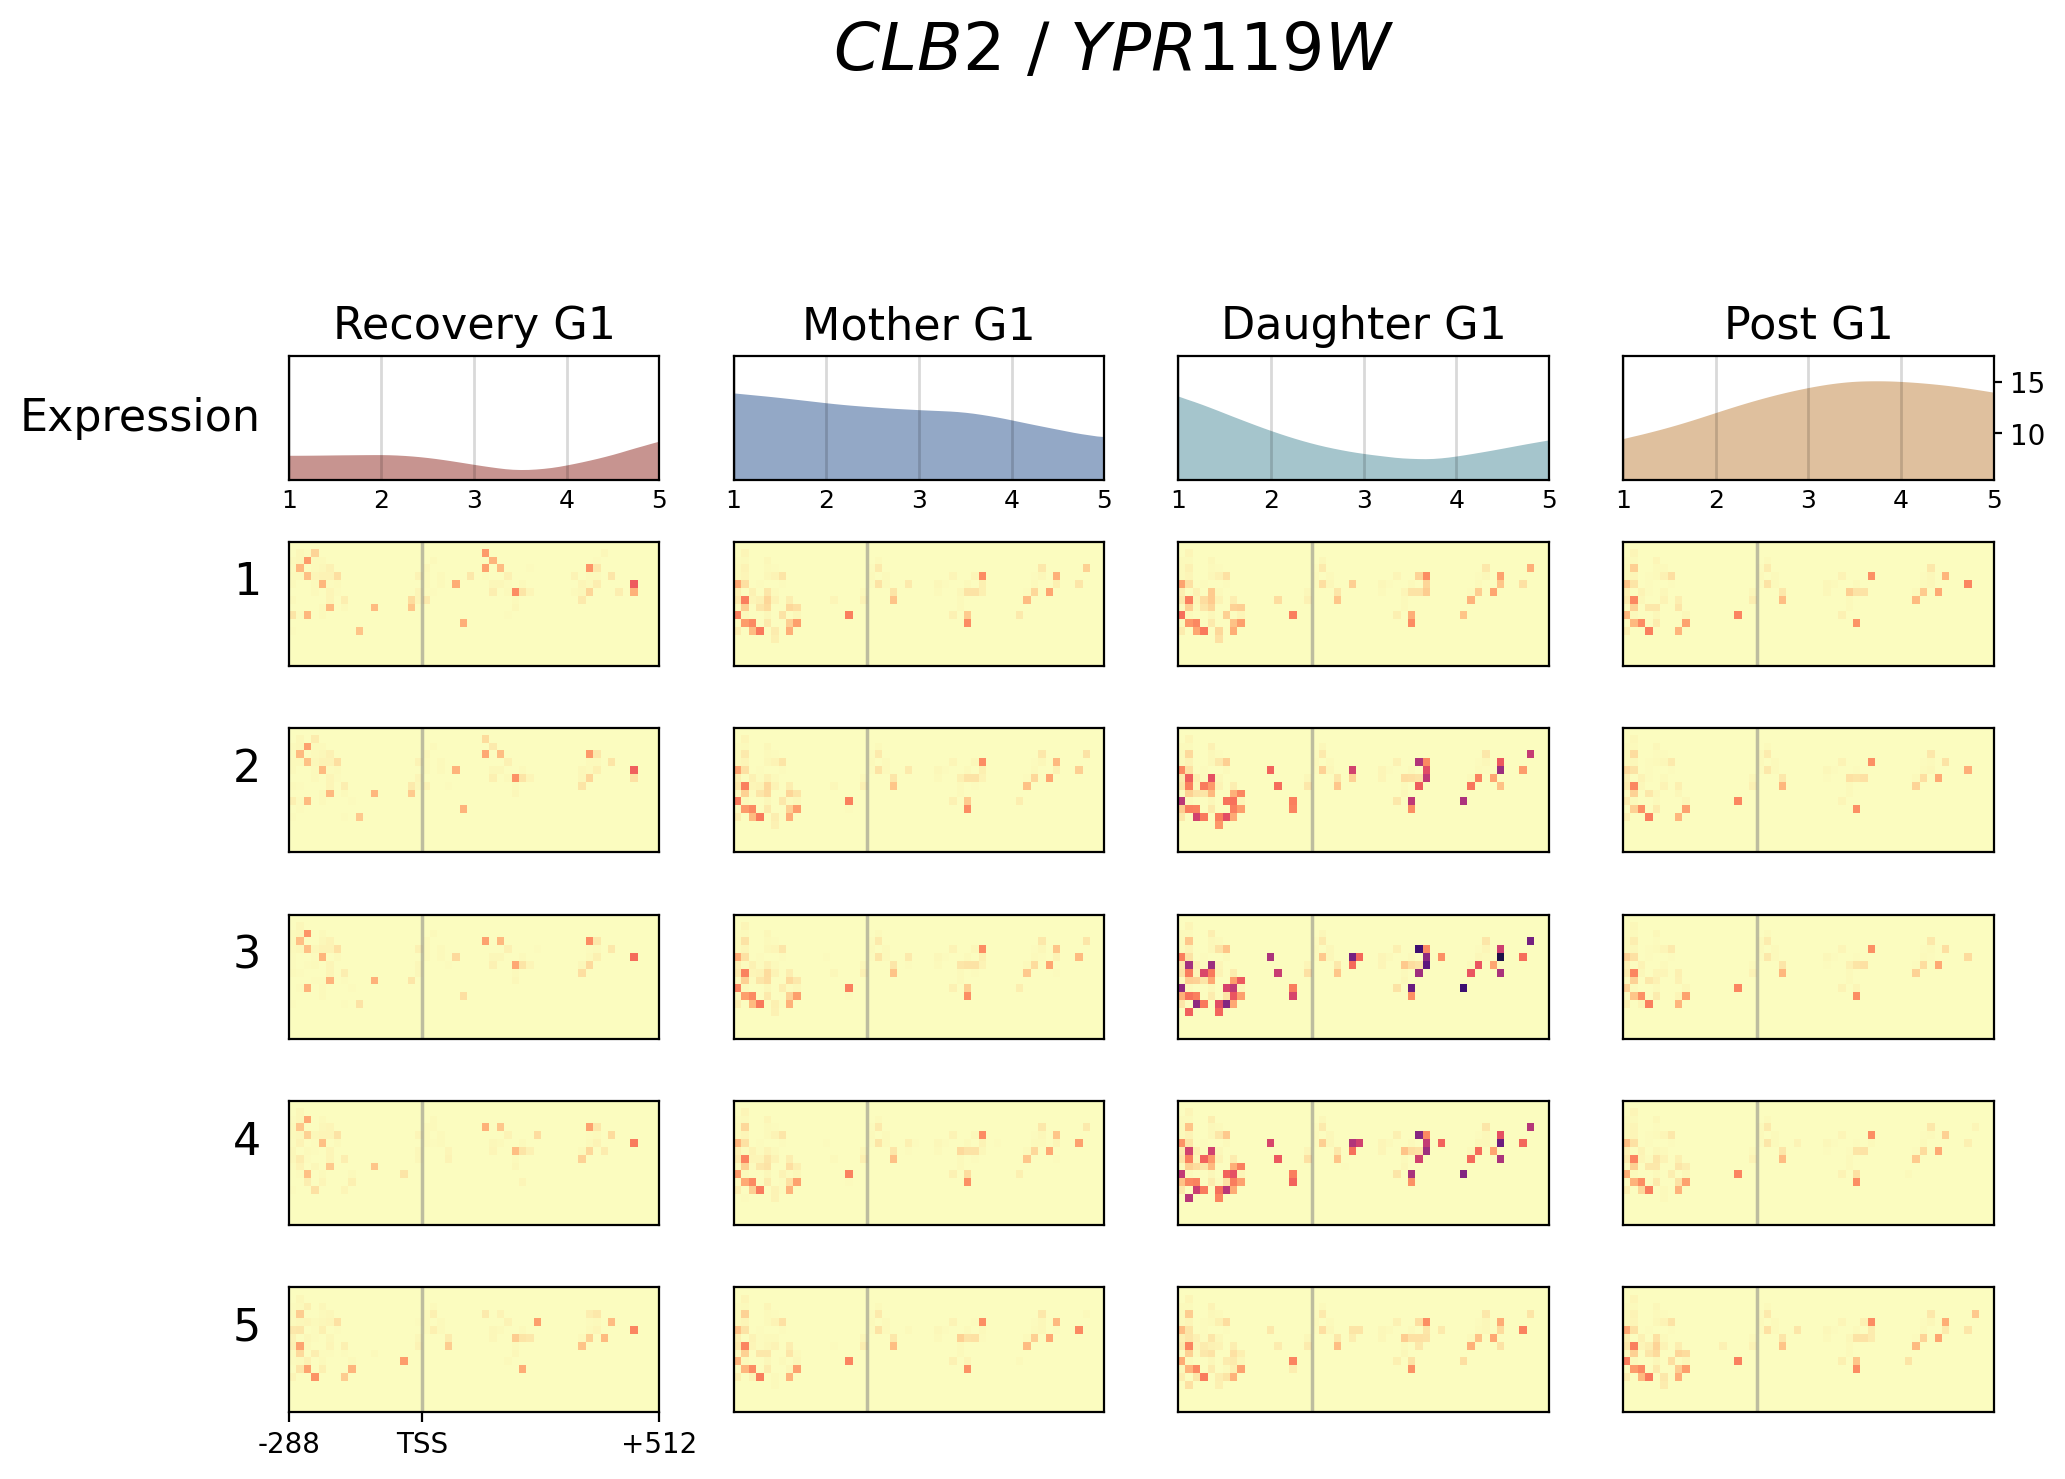

In [26]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(vmax=10, ge_model=ge_model)
